In [8]:
import pandas as pd
df = pd.read_csv('/content/car_sales_data.csv')
print(df.columns.tolist())

['Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture', 'Mileage', 'Price']


R2 Score: 0.998
Mean Absolute Error: 332.43


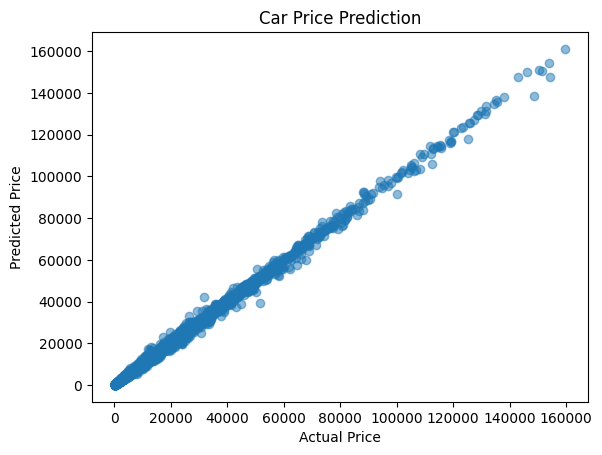

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load data (nee file path ne)
df = pd.read_csv('/content/car_sales_data.csv')

# 2. Handle categorical data
le = LabelEncoder()
for col in ['Manufacturer', 'Model', 'Fuel type']:
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Features and Target - Task 3 lo Price ni predict cheyali
X = df.drop('Price', axis=1)
y = df['Price']

# 4. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluation
pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, pred):.2f}")

# 7. Graph for report
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Car Price Prediction")
plt.show()

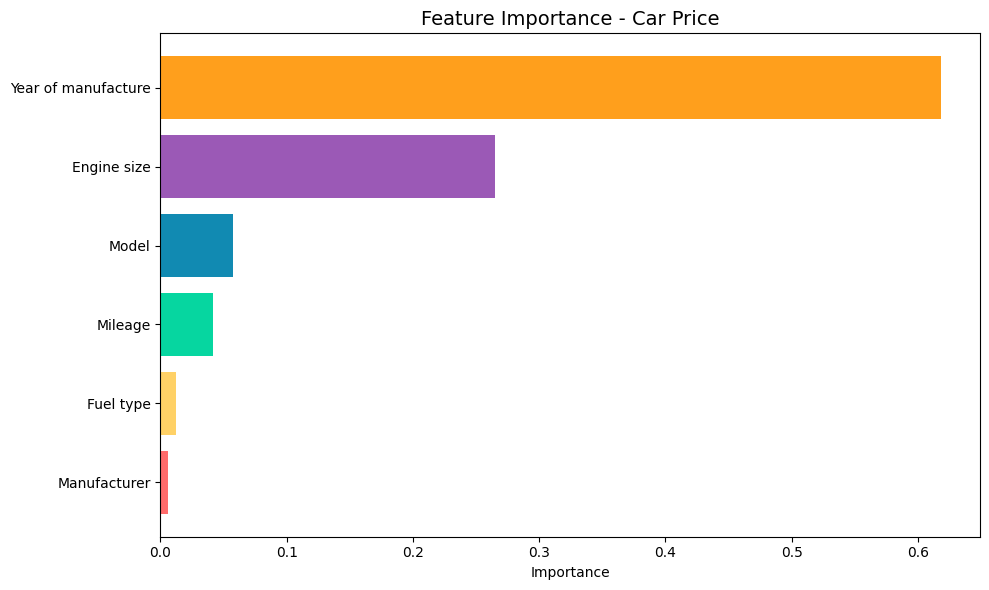

In [15]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns
sorted_idx = importances.argsort()

# Different color for each bar
colors = ['#FF6B6B', '#FFD166', '#06D6A0', '#118AB2', '#9B59B6', '#FF9F1C']

plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], importances[sorted_idx], color=colors[:len(features)])
plt.title("Feature Importance - Car Price", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()